<a href="https://colab.research.google.com/github/Pensive1881/DSR44_2025/blob/main/scratchpad_mnist_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Obtain the data

In [1]:
import torch
import torchvision

In [2]:
from torchvision.datasets import MNIST

data_path = '../data/'
mnist = MNIST(data_path, download=True)

100%|██████████| 9.91M/9.91M [00:01<00:00, 6.08MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 160kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.52MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.29MB/s]


In [3]:
mnist[0]

(<PIL.Image.Image image mode=L size=28x28>, 5)

In [4]:
mnist[0][0]

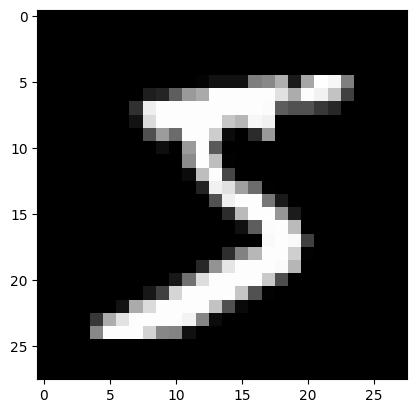

In [5]:
import matplotlib.pyplot as plt
plt.imshow(mnist[0][0], cmap='gray');

In [6]:
%%capture
!uv pip install fiftyone

In [7]:
import fiftyone.zoo as foz

train_dataset = foz.load_zoo_dataset('mnist', split='train')
test_testset = foz.load_zoo_dataset('mnist', split='test')

/usr/local/lib/python3.12/dist-packages/glob2/fnmatch.py:141: SyntaxWarning: invalid escape sequence '\Z'
  return '(?ms)' + res + '\Z'


INFO:fiftyone.zoo.datasets:Downloading split 'train' to '/root/fiftyone/mnist/train'
100%|██████████| 9.91M/9.91M [00:01<00:00, 6.05MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 161kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.52MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.22MB/s]

   0% |/------------|   175/60000 [100.8ms elapsed, 34.4s remaining, 1.7K samples/s] 

 100% |█████████████| 60000/60000 [25.9s elapsed, 0s remaining, 2.4K samples/s]      


INFO:eta.core.utils: 100% |█████████████| 60000/60000 [25.9s elapsed, 0s remaining, 2.4K samples/s]      


Dataset info written to '/root/fiftyone/mnist/info.json'


INFO:fiftyone.zoo.datasets:Dataset info written to '/root/fiftyone/mnist/info.json'


You are running the oldest supported major version of MongoDB. Please refer to https://deprecation.voxel51.com for deprecation notices. You can suppress this exception by setting your `database_validation` config parameter to `False`. See https://docs.voxel51.com/user_guide/config.html#configuring-a-mongodb-connection for more information


Loading 'mnist' split 'train'


INFO:fiftyone.zoo.datasets:Loading 'mnist' split 'train'


 100% |█████████████| 60000/60000 [44.5s elapsed, 0s remaining, 1.1K samples/s]       


INFO:eta.core.utils: 100% |█████████████| 60000/60000 [44.5s elapsed, 0s remaining, 1.1K samples/s]       


Dataset 'mnist-train' created


INFO:fiftyone.zoo.datasets:Dataset 'mnist-train' created


INFO:fiftyone.zoo.datasets:Downloading split 'test' to '/root/fiftyone/mnist/test'
100%|██████████| 9.91M/9.91M [00:01<00:00, 5.92MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 160kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.52MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.30MB/s]

   3% |/------------|   260/10000 [100.6ms elapsed, 3.8s remaining, 2.6K samples/s] 

 100% |█████████████| 10000/10000 [4.4s elapsed, 0s remaining, 1.7K samples/s]      


INFO:eta.core.utils: 100% |█████████████| 10000/10000 [4.4s elapsed, 0s remaining, 1.7K samples/s]      


Dataset info written to '/root/fiftyone/mnist/info.json'


INFO:fiftyone.zoo.datasets:Dataset info written to '/root/fiftyone/mnist/info.json'


Loading 'mnist' split 'test'


INFO:fiftyone.zoo.datasets:Loading 'mnist' split 'test'


 100% |█████████████| 10000/10000 [7.5s elapsed, 0s remaining, 1.5K samples/s]        


INFO:eta.core.utils: 100% |█████████████| 10000/10000 [7.5s elapsed, 0s remaining, 1.5K samples/s]        


Dataset 'mnist-test' created


INFO:fiftyone.zoo.datasets:Dataset 'mnist-test' created


In [8]:
import fiftyone as fo

session = fo.launch_app(train_dataset, auto=False)
print(session.url)

Session launched. Run `session.show()` to open the App in a cell output.


INFO:fiftyone.core.session.session:Session launched. Run `session.show()` to open the App in a cell output.



Welcome to

███████╗██╗███████╗████████╗██╗   ██╗ ██████╗ ███╗   ██╗███████╗
██╔════╝██║██╔════╝╚══██╔══╝╚██╗ ██╔╝██╔═══██╗████╗  ██║██╔════╝
█████╗  ██║█████╗     ██║    ╚████╔╝ ██║   ██║██╔██╗ ██║█████╗
██╔══╝  ██║██╔══╝     ██║     ╚██╔╝  ██║   ██║██║╚██╗██║██╔══╝
██║     ██║██║        ██║      ██║   ╚██████╔╝██║ ╚████║███████╗
╚═╝     ╚═╝╚═╝        ╚═╝      ╚═╝    ╚═════╝ ╚═╝  ╚═══╝╚══════╝ v1.8.1

If you're finding FiftyOne helpful, here's how you can get involved:

|
|  ⭐⭐⭐ Give the project a star on GitHub ⭐⭐⭐
|  https://github.com/voxel51/fiftyone
|
|  🚀🚀🚀 Join the FiftyOne Discord community 🚀🚀🚀
|  https://community.voxel51.com/
|



INFO:fiftyone.core.session.session:
Welcome to

███████╗██╗███████╗████████╗██╗   ██╗ ██████╗ ███╗   ██╗███████╗
██╔════╝██║██╔════╝╚══██╔══╝╚██╗ ██╔╝██╔═══██╗████╗  ██║██╔════╝
█████╗  ██║█████╗     ██║    ╚████╔╝ ██║   ██║██╔██╗ ██║█████╗
██╔══╝  ██║██╔══╝     ██║     ╚██╔╝  ██║   ██║██║╚██╗██║██╔══╝
██║     ██║██║        ██║      ██║   ╚██████╔╝██║ ╚████║███████╗
╚═╝     ╚═╝╚═╝        ╚═╝      ╚═╝    ╚═════╝ ╚═╝  ╚═══╝╚══════╝ v1.8.1

If you're finding FiftyOne helpful, here's how you can get involved:

|
|  ⭐⭐⭐ Give the project a star on GitHub ⭐⭐⭐
|  https://github.com/voxel51/fiftyone
|
|  🚀🚀🚀 Join the FiftyOne Discord community 🚀🚀🚀
|  https://community.voxel51.com/
|



https://5151-m-s-117mkihsoc12m-a.asia-east1-1.prod.colab.dev?polling=true
